### Tokenizer의 이해
![토큰화 프로세스](https://github.com/chulminkw/transformer_class/blob/main/images/tokenizer_process.png?raw=true)

In [1]:
import re #정규표현식

text = "Hello, world! I am learning NLP."

def normalize(text):
    text = text.lower() #소문자 일괄 변환
    text = re.sub(r"[^a-z0-9\s]", "", text) #숫자와 영문자, 스페이스가 아닌 특수기호(마침표등)는 모두 제거
    return text

normalized = normalize(text)
print("Normalized:", normalized)

Normalized: hello world i am learning nlp


In [2]:
def split_tokens(text):
    return text.split()

tokens = split_tokens(normalized)
print("Tokens:", tokens)
#공백을 쪼개서 리스트로 반환

Tokens: ['hello', 'world', 'i', 'am', 'learning', 'nlp']


In [3]:
def normalize_and_split(text):
    # 일괄 소문자 변환
    text = text.lower()
    # \b는 word boundary(단어와 단어 사이 공백이나 마침표등), w+는 한개 이상의 word 문자열 [a-zA-Z0-9_]
    tokens = re.findall(r"\b\w+\b", text) #앞에서 한거 다해줌
    return tokens

tokens = normalize_and_split(text)
print("Tokens:", tokens)

Tokens: ['hello', 'world', 'i', 'am', 'learning', 'nlp']


In [5]:
sorted(set(tokens)) #중복제거

['am', 'hello', 'i', 'learning', 'nlp', 'world']

In [4]:
# 토큰이 key, index값이 value인 dictionary로 어휘 사전 구축.
vocab = {word: idx for idx, word in enumerate(sorted(set(tokens)), start=2)} #각 토큰은 고유하게
# 특수 토큰 <PAD>, <UNK> index 지정.
vocab["<PAD>"] = 0 #PAD를 넣어 각 문장들의 길이 맞춰주기
vocab["<UNK>"] = 1 #모르는 단어가 들어왔을때
# 역 어휘사전 구축(index값이 key, 토큰이 value인 dictionary로)
inv_vocab = {v: k for k, v in vocab.items()}

print(vocab)
print(inv_vocab)#역어휘사전

{'am': 2, 'hello': 3, 'i': 4, 'learning': 5, 'nlp': 6, 'world': 7, '<PAD>': 0, '<UNK>': 1}
{2: 'am', 3: 'hello', 4: 'i', 5: 'learning', 6: 'nlp', 7: 'world', 0: '<PAD>', 1: '<UNK>'}


In [6]:
# 텍스트를 입력 받아 token index값 list로 반환
#text = "Hello, world! I am learning NLP."

def encode(text):
    tokens = normalize_and_split(text) #리스트로 된 토큰 값이 나옴, 정규화
    return [vocab.get(token, vocab["<UNK>"]) for token in tokens]

# list로 token index값들을 입력 받아 token 값 list로 반환
def decode(indices):
    return [inv_vocab.get(idx, "<UNK>") for idx in indices] #idx가 없으면 UNK로 해라

encoded = encode(text)
print("Encoded:", encoded)
print("Decoded:", decode(encoded))#토큰 인덱스를 단어로 다시 바꿈

Encoded: [3, 7, 4, 2, 5, 6]
Decoded: ['hello', 'world', 'i', 'am', 'learning', 'nlp']


In [7]:
import re

class SimpleTokenizer:
    def __init__(self):
        # 어휘 사전 및 역 단어 사전 dictionary 초기화
        self.vocab = {"<PAD>": 0, "<UNK>": 1}
        self.inv_vocab = {0: "<PAD>", 1: "<UNK>"}

    # 문자열 정규화 및 토큰 분할
    def normalize_and_split(self, text):
        text = text.lower()
        tokens = re.findall(r"\b\w+\b", text)
        return tokens

    # 단어 사전 및 역 단어 사전 구성. 단일 문장이 아닌, 여러 문장들을 list로 가지는 말뭉치(corpus)를 인자로 받음.
    def build_vocab(self, corpus):
        # <PAD>, <UNK> 이후에 token index 부여
        idx = len(self.vocab) #2번부터 할당
        for sentence in corpus:
            tokens = self.normalize_and_split(sentence)
            for token in tokens:
                if token not in self.vocab: #중복 제거용 (이미 있는 토큰이 아닐때만 인덱스화)
                    self.vocab[token] = idx #2번부터 넣음
                    self.inv_vocab[idx] = token
                    idx += 1

    def encode(self, text):
        tokens = self.normalize_and_split(text)
        return [self.vocab.get(token, self.vocab["<UNK>"]) for token in tokens]

    def decode(self, ids):
        return [self.inv_vocab.get(i, "<UNK>") for i in ids]

    # 최대 토큰 길이만큼(max_len) <PAD>의 index 별도 추가
    def pad(self, ids, max_len):
        return ids + [self.vocab["<PAD>"]] * (max_len - len(ids))# <PAD>를 갯수 맞추기 위해 곱(반복)함

    # callable로 객체 호출. text의 token index list 반환. max_len값이 설정 시 max_len 만큼 <PAD> 별도 추가.
    def __call__(self, text, max_len=None):
        ids = self.encode(text)
        if max_len:
            ids = self.pad(ids, max_len)
        return ids


In [8]:
s_tokenizer = SimpleTokenizer()

# build_vocab()을 호출하기 전에는 vocab이 비어 있음
print(s_tokenizer.vocab)
print(s_tokenizer.encode('this is test'))

{'<PAD>': 0, '<UNK>': 1}
[1, 1, 1]


In [9]:
corpus = [
    "The cat sat on the mat.",
    "I love natural language processing.",
    "How are you doing today?",
    "She sells seashells by the seashore.",
    "Artificial intelligence is transforming the world.",
    "Can you believe it's already July?",
    "Let's meet at 5 p.m. in the cafe.",
    "He didn’t know what to say.",
    "The weather is nice and sunny.",
    "Data science combines statistics and programming.",
    "Despite the heavy rain and traffic, she arrived on time with a smile on her face."
]

s_tokenizer = SimpleTokenizer()
s_tokenizer.build_vocab(corpus) #어휘 사전이 만들어짐
print(s_tokenizer.vocab)


{'<PAD>': 0, '<UNK>': 1, 'the': 2, 'cat': 3, 'sat': 4, 'on': 5, 'mat': 6, 'i': 7, 'love': 8, 'natural': 9, 'language': 10, 'processing': 11, 'how': 12, 'are': 13, 'you': 14, 'doing': 15, 'today': 16, 'she': 17, 'sells': 18, 'seashells': 19, 'by': 20, 'seashore': 21, 'artificial': 22, 'intelligence': 23, 'is': 24, 'transforming': 25, 'world': 26, 'can': 27, 'believe': 28, 'it': 29, 's': 30, 'already': 31, 'july': 32, 'let': 33, 'meet': 34, 'at': 35, '5': 36, 'p': 37, 'm': 38, 'in': 39, 'cafe': 40, 'he': 41, 'didn': 42, 't': 43, 'know': 44, 'what': 45, 'to': 46, 'say': 47, 'weather': 48, 'nice': 49, 'and': 50, 'sunny': 51, 'data': 52, 'science': 53, 'combines': 54, 'statistics': 55, 'programming': 56, 'despite': 57, 'heavy': 58, 'rain': 59, 'traffic': 60, 'arrived': 61, 'time': 62, 'with': 63, 'a': 64, 'smile': 65, 'her': 66, 'face': 67}


In [10]:
# 문장을 token index list로, "The cat sat on the mat."
token_ids = s_tokenizer.encode("The cat sat on the mat.")
print(token_ids)
print(s_tokenizer.decode(token_ids))

# callable 로 호출. max_len 지정 시 max_len 만큼 <PAD> 별도 추가
token_ids = s_tokenizer("The cat sat on the mat.", max_len=20)# max_len = 20
print(token_ids)
print(s_tokenizer.decode(token_ids))

[2, 3, 4, 5, 2, 6]
['the', 'cat', 'sat', 'on', 'the', 'mat']
[2, 3, 4, 5, 2, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
['the', 'cat', 'sat', 'on', 'the', 'mat', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']


In [11]:
# 어휘 사전에 없는 토큰은 <UNK>로
token_ids = s_tokenizer("She is the most beautiful girl in the world", max_len=20)# max_len = 20
print(token_ids)
print(s_tokenizer.decode(token_ids))

[17, 24, 2, 1, 1, 1, 39, 2, 26, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
['she', 'is', 'the', '<UNK>', '<UNK>', '<UNK>', 'in', 'the', 'world', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']


### nn.Embedding 살펴보기
![embedding](https://github.com/chulminkw/transformer_class/blob/main/images/embedding.png?raw=true)

In [12]:
import torch
import torch.nn as nn

torch.manual_seed(123)

# Embedding 생성 파라미터
vocab_size = 8        #단어 사전의 token 갯수()
embedding_dim = 32      #Embedding Vector 크기

# nn.Embedding 생성
embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embedding_dim,
                         padding_idx=0)# <PAD>는 0이니 0을 넣어줌, pad는 모델 역전파 학습시 제외
print(embedding)
print(embedding.weight)

Embedding(8, 32, padding_idx=0)
Parameter containing:
tensor([[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-1.3250e+00,  1.7843e-01, -2.1338e+00,  1.0524e+00, -3.8848e-01,
         -9.3435e-01, -4.9914e-01, -1.0867e+00,  8.8054e-01,  1.5542e+00,
          6.2662e-01, -1.7549e-01,  9.8284e-02, -9.3507e-02,  2.6621e-01,
         -5.8504e-01,  8.7684e-01,  1.6221e+00, -1.4779e+00,  1.1331e+00,
         -1.2203e+00,  1.3139e+00,  1.0533e+00,  1.3881e-01,  2.2473e+00,
         -8.0364e-01, -2.8084e-01,  7.6968e-01, -6.5956e-01, -7.9793e-01,
          1.8383e-01, 

In [13]:
# token 인덱스값.
token_ids_tensor = torch.tensor([0, 2, 5], dtype=torch.long)

# callable 호출로 token index(tensor값이어야 함)를 입력하고 index에 해당하는 embedding vector값 반환.
embedded = embedding(token_ids_tensor) #토큰의 인덱스 값이 들어감
print("Embedding vectors:")
print(embedded)

Embedding vectors:
tensor([[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.5146,  0.9938, -0.2587, -1.0826, -0.0444,  1.6236, -2.3229,  1.0878,
          0.6716,  0.6933, -0.9487, -0.0765, -0.1526,  0.1167,  0.4403, -1.4465,
          0.2553, -0.5496,  1.0042,  0.8272, -0.3948,  0.4892, -0.2168, -1.7472,
         -1.6025, -1.0764,  0.9031, -0.7218, -0.5951, -0.7112,  0.6230, -1.3729],
        [ 0.6851,  2.0024, -0.5469,  1.6014, -2.2577, -1.8009,  0.7015,  0.5703,
         -1.1766, -2.0524,  0.1132,  1.4353,  0.0883, -1.2037,  1.0964,  2.4210,
          0.1538, -0.4452,  0.5503,  0.0658,  0.6805,  1.2064,  1.6250,  0.3459,
          0.1343,  0.7662,  2.2760, -1.3255, -0.8970,  0.1132,  0.8365,  0.0285]],
     

In [14]:
# corpus (말뭉치) 기반으로 SimpleTokenizer의 단어(어휘)사전 구축

corpus = [
    "The cat sat on the mat.",
    "I love natural language processing.",
    "How are you doing today?",
    "She sells seashells by the seashore.",
    "Artificial intelligence is transforming the world.",
    "Can you believe it's already July?",
    "Let's meet at 5 p.m. in the cafe.",
    "He didn’t know what to say.",
    "The weather is nice and sunny.",
    "Data science combines statistics and programming.",
    "Despite the heavy rain and traffic, she arrived on time with a smile on her face."
]

s_tokenizer = SimpleTokenizer()
s_tokenizer.build_vocab(corpus)
print(s_tokenizer.vocab)

{'<PAD>': 0, '<UNK>': 1, 'the': 2, 'cat': 3, 'sat': 4, 'on': 5, 'mat': 6, 'i': 7, 'love': 8, 'natural': 9, 'language': 10, 'processing': 11, 'how': 12, 'are': 13, 'you': 14, 'doing': 15, 'today': 16, 'she': 17, 'sells': 18, 'seashells': 19, 'by': 20, 'seashore': 21, 'artificial': 22, 'intelligence': 23, 'is': 24, 'transforming': 25, 'world': 26, 'can': 27, 'believe': 28, 'it': 29, 's': 30, 'already': 31, 'july': 32, 'let': 33, 'meet': 34, 'at': 35, '5': 36, 'p': 37, 'm': 38, 'in': 39, 'cafe': 40, 'he': 41, 'didn': 42, 't': 43, 'know': 44, 'what': 45, 'to': 46, 'say': 47, 'weather': 48, 'nice': 49, 'and': 50, 'sunny': 51, 'data': 52, 'science': 53, 'combines': 54, 'statistics': 55, 'programming': 56, 'despite': 57, 'heavy': 58, 'rain': 59, 'traffic': 60, 'arrived': 61, 'time': 62, 'with': 63, 'a': 64, 'smile': 65, 'her': 66, 'face': 67}


In [15]:
# tokenizer의 단어 사전 크기를 인자로 입력 받아 embedding 생성.
vocab_size = len(s_tokenizer.vocab) # #단어 사전의 token 갯수(단어 사전 크기)
embedding_dim = 128  #Embedding Vector 크기

embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embedding_dim)
print(embedding)
print(embedding.weight.shape )

Embedding(68, 128)
torch.Size([68, 128])


In [16]:
token_ids_list = s_tokenizer("The cat sat on the mat.", max_len=20)# It is going to rain soon
print(token_ids_list) #단어 인덱스 토큰 인덱스 가져오기

embedded = embedding(torch.tensor(token_ids_list, dtype=torch.long))
print(embedded.shape)

[2, 3, 4, 5, 2, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
torch.Size([20, 128])


#### Embedding vectors 값 시각화
* HuggingFace BERT 모델의 Embedding Layer에서 유사한 token들의 embedding 값을 2차원 평면에 시각화

In [17]:
from transformers import BertModel, BertTokenizer
import torch
import torch.nn as nn

# model & tokenizer를 로딩.
# pretrained 모델을 활용할 때는 해당 모델 학습 시에 적용된 tokenizer를 이용해야 함.
# tokenizer의 토큰 index와 pretrained 모델의 embedding이 서로 loosely 연결되어 있기 때문에...
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased") #이름을 똑같이 적어줘야 한다
model = BertModel.from_pretrained("bert-base-uncased")

#아래는 pretrained된 모델의 embedding값을 초기화함. pretrained되지 않은 embedding 값을 시각화 할때 사용.
# nn.init.normal_(model.embeddings.word_embeddings.weight, mean=0.0, std=0.02)

# embedding layer 가져옴. (nn.Embedding)
embedding_layer = model.embeddings.word_embeddings

print(embedding_layer)
print(embedding_layer.weight.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding(30522, 768, padding_idx=0)
torch.Size([30522, 768])


In [19]:
# 시각화할 단어들의 token index값을 tokenizer에서 추출
words = ["king", "queen", "man", "woman", "paris", "france", "london", "england"]
input_ids = [tokenizer.convert_tokens_to_ids(word) for word in words] #임베딩에 들어갈건 토큰 인덱스 값

# embedding layer(nn.Embedding)에서 위 token들의 embedding vector값 가져옴.
embedding_vectors = embedding_layer(torch.tensor(input_ids, dtype=torch.long))  # shape (len(words), 768)

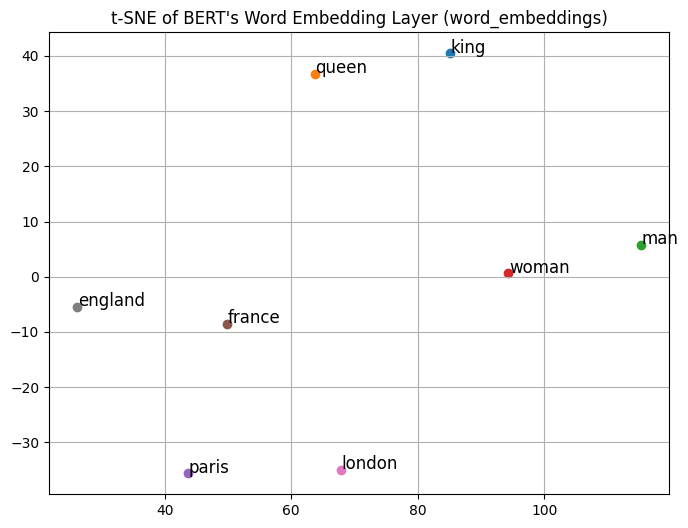

In [20]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# t-SNE 적용을 위해 tensor를 numpy로 변환.
vectors = embedding_vectors.detach().numpy()

# t-SNE 적용
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
reduced = tsne.fit_transform(vectors)

# 시각화
plt.figure(figsize=(8, 6))
for i, word in enumerate(words):
    x, y = reduced[i]
    plt.scatter(x, y)
    plt.annotate(word, (x + 0.1, y + 0.1), fontsize=12)
plt.title("t-SNE of BERT's Word Embedding Layer (word_embeddings)")
plt.grid(True)
plt.show()

### RNN 모델 살펴보기

![RNN 모델](https://github.com/chulminkw/transformer_class/blob/main/images/rnn_model_01.png?raw=true)

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F

#embed_dim은 입력 token의 embedding dim(size), hidden_dim은 Hidden status의 (맨 마지막) 차원 크기.
embed_dim = 128
hidden_dim = 256

rnn_model = nn.RNN(input_size=embed_dim, #입력으로 들어오는 단어 토큰 임베딩 사이즈, 학습 파라미터 사이즈 결정
                   hidden_size=hidden_dim,
                   num_layers=1, batch_first=True) #batch_first=False
                   #num_layers가 1이면 순차적인것, 2이면 역순

In [26]:
rnn_model.named_parameters()

<generator object Module.named_parameters at 0x7d821133e940>

In [27]:
# RNN 모델의 Learnable Parameter 확인.
# Hidden status 용 Weight의 Shape는 (hidden_dim, hidden_dim)
# 입력 token용 Weight shape는 (hidden_dim, embed_dim) -> transpose하면 (emced_dim, hid_dim)
for name, param in rnn_model.named_parameters():
    print(name, param.shape)
    # print(param)
#weight_ih= Wx
#weight_hh= Wh
# X * Wx'이니까 embed_dim * (embed_dim, hid_dim) = hid_dim

weight_ih_l0 torch.Size([256, 128])
weight_hh_l0 torch.Size([256, 256])
bias_ih_l0 torch.Size([256])
bias_hh_l0 torch.Size([256])


In [29]:
!pip install torchinfo

In [30]:
from torchinfo import summary

seq_len = 60 # 600으로 변경하면 ?
# sequence length를 증가시켜도 Learnable Parameter 크기의 변화가 없음.
# Learnable Parameter 는 input embed 크기와 hidden state의 크기에 영향
# input은 (batch_size=4, seq_len=60, embed_dim=128)
summary(rnn_model, input_size=(4, seq_len, embed_dim),
        col_names=["input_size", "output_size", "num_params"],
        verbose=2,
       )

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
RNN                                      [4, 60, 128]              [4, 60, 256]              98,816
├─weight_ih_l0                                                                               ├─32,768
├─weight_hh_l0                                                                               ├─65,536
├─bias_ih_l0                                                                                 ├─256
├─bias_hh_l0                                                                                 └─256
Total params: 98,816
Trainable params: 98,816
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 23.72
Input size (MB): 0.12
Forward/backward pass size (MB): 0.49
Params size (MB): 0.40
Estimated Total Size (MB): 1.01


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
RNN                                      [4, 60, 128]              [4, 60, 256]              98,816
├─weight_ih_l0                                                                               ├─32,768
├─weight_hh_l0                                                                               ├─65,536
├─bias_ih_l0                                                                                 ├─256
├─bias_hh_l0                                                                                 └─256
Total params: 98,816
Trainable params: 98,816
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 23.72
Input size (MB): 0.12
Forward/backward pass size (MB): 0.49
Params size (MB): 0.40
Estimated Total Size (MB): 1.01

#### 생성된 RNN모델에 문장 입력 token을 forward 시켜 반환되는 출력 살펴보기

In [31]:
torch.manual_seed(123)

vocab_size = 1000
batch_size = 4
seq_len = 60 # 600으로 변경하면
embed_dim = 128

# 생성된 RNN 모델의 forward용 입력 embedded tensor 생성.
embedding = nn.Embedding(vocab_size, embed_dim)
batched_sample_token_ids = torch.randint(low=0, high=vocab_size, size=(batch_size, seq_len), dtype=torch.long)

embedded = embedding(batched_sample_token_ids)
print(f"embedded shape:{embedded.shape}")
print(f"batched_sample_token_ids shape:{batched_sample_token_ids.shape}")
print(f"batched_sample_token_ids: \n{batched_sample_token_ids}")

embedded shape:torch.Size([4, 60, 128])
batched_sample_token_ids shape:torch.Size([4, 60])
batched_sample_token_ids: 
tensor([[840, 639, 818, 350, 255, 107, 964, 319, 187, 122, 963, 360, 538, 646,
         242, 211, 371, 240, 607, 979, 748, 842, 203, 151, 131, 257, 169, 191,
         199, 780, 868, 211, 510, 711, 761, 599, 615, 511, 526, 850, 213, 572,
         199, 216, 133,  23, 620, 964, 530, 469, 141,   4, 546, 804, 386, 638,
         773, 729, 391, 449],
        [529, 891, 591, 753, 330, 802, 450, 351, 497, 581, 670, 920, 142, 714,
         665, 454, 624, 161, 995, 431, 152, 304, 938, 252, 460, 127,  12, 871,
         726, 639, 345, 327, 637, 648, 653, 533, 447, 580, 384, 184, 550, 124,
         715, 648,  37, 183, 800, 942, 574, 393, 262, 470, 327, 156, 614, 605,
         804, 936, 707, 662],
        [303, 116, 359, 152, 849, 356,  16, 426, 357, 778, 162, 300, 889, 215,
         155, 693, 974, 879, 931, 924, 555,  36, 159, 345, 761, 781,  85, 795,
         335, 858,  93, 780, 952

In [32]:
torch.manual_seed(123)

hidden_dim = 256

rnn_model = nn.RNN(input_size=embed_dim,
                   hidden_size=hidden_dim, num_layers=1,
                   batch_first=True) #batch_first=False

#RNN 모델에 입력 embed 값을 forward 시키면 2개의 tensor를 반환.
#outputs는 sequence 별 입력값에 대한 hidden status 출력값. sequence 순서에 맞춰 입력된 값을 sequence 순서에 맞춰 출력함.
#sequence 입력에 따라 순차적으로 출력이 생기지만, outputs 자체는 모든 sequence가 출력 처리된 다음에 묶어서 반환됨.
#즉 outputs의 shape는 (batch_size, seq_len, hidden_dim)임.
# last_hidden은 sequence의 마지막에서 만들어 지는 hidden status 값.
# 연산 결과 shape는 (batch_size, hidden_dim)이 되지만 3차원으로 통일 시켜서 (1, batch_size, hidden_dim)
outputs, last_hidden = rnn_model(embedded) #outputs: (batch_size, seq_len, hidden_dim), last_hidden: (1, batch_size, hidden_dim)
print(outputs.shape, last_hidden.shape)

torch.Size([4, 60, 256]) torch.Size([1, 4, 256])


In [33]:
print(f"outputs에서 first batch의 마지막 hidden status값:\n{outputs[0, 59]}")
print(f"first batch의 마지막 hidden status 값:\n{last_hidden[0, 0]}")

outputs에서 first batch의 마지막 hidden status값:
tensor([ 0.1605, -0.1521,  0.4249, -0.3023,  0.5515, -0.1458,  0.4677, -0.5134,
        -0.2150,  0.3146,  0.0926, -0.1050,  0.0427, -0.5468,  0.7460, -0.1892,
         0.5749, -0.5692, -0.7459, -0.3734, -0.5936, -0.2698,  0.2334,  0.7303,
        -0.0463, -0.4210,  0.4785, -0.2473, -0.3829, -0.3406,  0.5407, -0.4698,
         0.2815, -0.4045,  0.7793, -0.7296,  0.4932, -0.0355,  0.5460, -0.3121,
         0.1110, -0.2093, -0.0967, -0.3238,  0.6574,  0.2180, -0.2754,  0.6633,
         0.1207, -0.7571, -0.0187,  0.2262, -0.6128,  0.5269, -0.7077,  0.3235,
         0.4346, -0.6973, -0.3762, -0.2546, -0.3321,  0.4365, -0.4638,  0.1281,
         0.5493,  0.4653, -0.4353,  0.5207,  0.4276, -0.5202,  0.0239, -0.7227,
         0.4542,  0.4002,  0.1464,  0.0078, -0.3912,  0.1018, -0.2719,  0.4109,
        -0.4493,  0.4207, -0.7114,  0.2513,  0.4971,  0.3289,  0.6099, -0.3250,
         0.2804, -0.3519, -0.4128,  0.3836,  0.2514, -0.1377, -0.1789, -0.083

In [34]:
# sequence length를 증가시켜도 Learnable Parameter 크기의 변화가 없음.
# Learnable Parameter 는 input embed 크기와 hidden state의 크기에 영향
summary(rnn_model, input_size=(4, seq_len, embed_dim),
        col_names=["input_size", "output_size", "num_params"],
        verbose=2,
       )

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
RNN                                      [4, 60, 128]              [4, 60, 256]              98,816
├─weight_ih_l0                                                                               ├─32,768
├─weight_hh_l0                                                                               ├─65,536
├─bias_ih_l0                                                                                 ├─256
├─bias_hh_l0                                                                                 └─256
Total params: 98,816
Trainable params: 98,816
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 23.72
Input size (MB): 0.12
Forward/backward pass size (MB): 0.49
Params size (MB): 0.40
Estimated Total Size (MB): 1.01


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
RNN                                      [4, 60, 128]              [4, 60, 256]              98,816
├─weight_ih_l0                                                                               ├─32,768
├─weight_hh_l0                                                                               ├─65,536
├─bias_ih_l0                                                                                 ├─256
├─bias_hh_l0                                                                                 └─256
Total params: 98,816
Trainable params: 98,816
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 23.72
Input size (MB): 0.12
Forward/backward pass size (MB): 0.49
Params size (MB): 0.40
Estimated Total Size (MB): 1.01

### RNN 기반의 Seq2Seq 모델 만들기
* Encoder와 Decoder 모듈을 만들고 Seq2Seq에서 이들을 활용
![Seq2Seq](https://github.com/chulminkw/transformer_class/blob/main/images/seq2seq.png?raw=true)


In [35]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim): #emb_dim= 입력 토큰 임베딩 디멘션
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.rnn = nn.GRU(emb_dim, hid_dim, batch_first=True)

    def forward(self, src):
        # src shape는 [batch, seq_len], 배치 단위 문장의 token_ids 가 입력됨.
        embedded = self.embedding(src) # (batch, seq_len, emb_dim)
        outputs, context_vecs = self.rnn(embedded) #outputs은 (batch, seq_len, hid_dim)
        # print(f"src shape:{src.shape} embedded shape:{embedded.shape}")
        # print(f"outputs shape:{outputs.shape} context_vecs shape:{context_vecs.shape}")
        return context_vecs

In [36]:
torch.manual_seed(123)
vocab_size = 1000
batch_size = 4
seq_len = 60
embed_dim = 128
hidden_dim = 256

#단어 사전에 있는 토큰의 인덱스 값을 넣음
batched_sample_token_ids = torch.randint(low=0, high=vocab_size, size=(batch_size, seq_len), dtype=torch.long)

encoder = Encoder(vocab_size=vocab_size, emb_dim=embed_dim, hid_dim=hidden_dim)
context_vecs = encoder(batched_sample_token_ids) # context_vecs shape: [1, batch_size, hidden_dim]
print(context_vecs.shape)

torch.Size([1, 4, 256])


In [37]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.rnn = nn.GRU(emb_dim, hid_dim, batch_first=True)
        self.fc_out = nn.Linear(hid_dim, vocab_size)

    def forward(self, input_token, hidden): #hidden= 컨텍스트 벡터
        #input_token shape: (batch), hidden: (1, batch, hid_dim)
        embedded = self.embedding(input_token).unsqueeze(1) #(batch, 1, emb_dim)
        output, hidden = self.rnn(embedded, hidden) # output: (batch, 1, hid_dim)
        prediction = self.fc_out(output.squeeze(1)) #(batch, output_dim)

        return prediction, hidden

In [38]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, max_len):
        batch_size = src.shape[0]
        vocab_size = self.decoder.fc_out.out_features
        outputs = torch.zeros(max_len, batch_size, vocab_size) #0으로 초기화

        hidden = self.encoder(src) # (1, batch_size, hid_dim)
        input_token = torch.full((batch_size,), 1, dtype=torch.long) # 여기서 1은 sos(start of sequence)

        for t in range(max_len): # 순차적으로 출력 sequence를 생성.
            output, hidden = self.decoder(input_token, hidden)
            outputs[t] = output #출력
            input_token = output.argmax(1)

        return outputs

In [39]:
batched_sample_token_ids = torch.randint(low=0, high=vocab_size, size=(batch_size, seq_len), dtype=torch.long)

encoder = Encoder(vocab_size=vocab_size, emb_dim=embed_dim, hid_dim=hidden_dim)
decoder = Decoder(vocab_size, embed_dim, hidden_dim)
seq2seq = Seq2Seq(encoder, decoder)

outputs = seq2seq(src=batched_sample_token_ids, max_len=seq_len)
print(f"outputs.shape:{outputs.shape}")

outputs.shape:torch.Size([60, 4, 1000])
